# Armed Conflict Location & Event Data Project (ACLED) EDA

In [1]:
import os
import math
import numpy as np
import pandas as pd
from scipy import stats

from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime

# !pip install -q openpyxl

In [2]:
def read_data(filename):
    '''Reads a dataset from the local path based on file type.'''
    base_path = ""
    full_path = os.path.join(base_path, filename)

    if filename.endswith('.xlsx') or filename.endswith('.xls'):
        return pd.read_excel(full_path)
    else:
        return pd.read_csv(full_path, sep=",", encoding='utf-8-sig')

    return df

In [3]:
# Armed Conflict Location & Event Data Project (ACLED) dataset
# Note: ACLED US coverage begins 2020
acled = read_data("ACLED Data_2026-08-02.csv")
print(acled.shape)
acled.head()

(87250, 32)


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp,population_best
0,USA23310,2020-01-01,2020,1,Demonstrations,Protests,Peaceful protest,Protesters (United States),Health Workers (United States),Protesters,...,41.4822,-81.6697,1,WKYC Studios; Crowd Counting Consortium,Other-Subnational,"On 1 January 2020, an unknown number of people...",0,crowd size=no report,1612546518,279.0
1,USA23416,2020-01-01,2020,1,Demonstrations,Protests,Peaceful protest,Protesters (United States),NaN,Protesters,...,43.1547,-77.6155,1,13WHAM ABC; Democrat and Chronicle; 10NBC,Subnational,"On 1 January 2020, people held a peace march o...",0,crowd size=no report,1612546518,2817.0
2,USA23636,2020-01-01,2020,1,Demonstrations,Protests,Peaceful protest,Protesters (United States),Government of the United States (2017-2021),Protesters,...,33.4492,-112.0741,1,Count Love; Channel 12 (Mesa),Other-Subnational,"On 1 January 2020, a group of people gathered ...",0,crowd size=no report,1612546518,9238.0
3,USA23414,2020-01-01,2020,1,Demonstrations,Protests,Peaceful protest,Protesters (United States),NaN,Protesters,...,40.7834,-73.9663,1,CBS2 (New York),Subnational,"On 1 January 2020, protesters gathered at NYPD...",0,crowd size=no report,1782931492,39247.0
4,USA23635,2020-01-01,2020,1,Demonstrations,Protests,Peaceful protest,Protesters (United States),BLM: Black Lives Matter,Protesters,...,37.8044,-122.2711,1,KTVU Fox2,Subnational,"On 1 January 2020, a group of people gathered ...",0,crowd size=no report,1612546519,14143.0


**Data Cleaning**

In [4]:
def clean_data(df):
    '''Filters by United States from 2020 to Present. 
    The ACLED data is one row per event.'''
    df = df.copy()

    # Filter country by United States (this is redundant for our current export but I wanted to make it reproducible)
    usa_mask = df['country'].str.lower().isin(['united states'])
    df_filtered = df[usa_mask].copy()

    # Convert 'event_date' to datetime and derive year / month
    df_filtered['event_date'] = pd.to_datetime(df_filtered['event_date'])
    df_filtered = df_filtered.dropna(subset=['event_date'])
    df_filtered['year'] = df_filtered['event_date'].dt.year
    df_filtered['month'] = df_filtered['event_date'].dt.to_period('M') # for monthly grouping

    # Filter out everything prior to 2020 (ACLED US coverage starts 2020-01-01, so this step is also redundant)
    df_filtered = df_filtered[df_filtered['year'] >= 2020]

    # ACLED names its geography fields admin1/admin2 admin1 is the state, admin2 is the county, and 'location' is the city
    df_filtered = df_filtered.rename(columns={'admin1': 'state', 'admin2': 'county'})

    # admin3 is empty for every row in this export iso and region fields are constant once filtered to the US
    df_filtered = df_filtered.drop(columns=['admin3', 'iso', 'region'])

    return df_filtered

In [5]:
acled_filtered = clean_data(acled)
acled_filtered['state'].unique()
print('Shape of US events', acled_filtered.shape)

# print(acled.columns)
# print(acled['event_type'].unique())
# print(acled['disorder_type'].unique())

# Filter for political violence / violent events only (based on ACLED codebook definitions)
acled_pv = acled_filtered[
    acled_filtered['disorder_type'].isin(['Political violence', 'Political violence; Demonstrations'])
    | (acled_filtered['sub_event_type'].isin(['Violent demonstration', 'Looting/property destruction']))]

print('Shape of violent US events', acled_pv.shape)
acled_pv.head(5)

Shape of US events (87250, 30)
Shape of violent US events (2600, 30)


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp,population_best,month
23,USA38674,2020-01-03,2020,1,Strategic developments,Strategic developments,Looting/property destruction,Sole Perpetrator (United States),NaN,Political militia,...,-75.7554,1,ABC News; Philadelphia Inquirer,National,"Property destruction: On 3 January 2020, a man...",0,NaN,1753970908,NaN,2020-01
1062,USA23916,2020-01-27,2020,1,Political violence,Violence against civilians,Attack,Police Forces of the United States (2017-2021),NaN,State forces,...,-76.9453,1,CNN; Killed by Police; New York Times; NewsCha...,Other-National,"On 27 January 2020, a police officer shot and ...",1,NaN,1754411458,87354.0,2020-01
1091,USA23768,2020-01-28,2020,1,Political violence,Riots,Mob violence,Rioters (United States),NaN,Rioters,...,-111.7322,1,KOIN6; St. George News,Subnational-National,"On 28 January 2020, six men physically and ver...",0,crowd size=6,1614122725,9027.0,2020-01
1162,USA31620,2020-01-31,2020,1,Political violence,Violence against civilians,Attack,Police Forces of the United States (2017-2021),NaN,State forces,...,-89.0928,1,WLOX ABC,Subnational,"On 31 January 2020, a police officer shot and ...",1,NaN,1754411458,22805.0,2020-01
1184,USA34305,2020-02-01,2020,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (United States),White Nationalists (United States); Christian ...,Political militia,...,-117.2306,1,Press-Enterprise; Anti-Defamation League,Subnational-National,"On 1 February 2020, two white men attacked and...",1,NaN,1631649215,140788.0,2020-02


In [6]:
# To validate the ACLED data, I checked against the ACLED's published number of political violence events by country-month-year
num_events = read_data("number_of_political_violence_events_by_country-month-year_as-of-24Jul2026.xlsx")
num_events.columns = num_events.columns.str.lower()

# ACLED already aggregated this data, so it just needs to be filtered by United States from 2020 to Present
published_df = num_events[num_events['country'] == 'United States'].copy()
published_df['month'] = pd.PeriodIndex(
    pd.to_datetime(published_df['month'] + ' 1 ' + published_df['year'].astype(str)), freq='M')

print('Shape of US political violence counts', published_df.shape)
published_df.head()


Shape of US political violence counts (79, 4)


,country,month,year,events
27475,United States,2020-01,2020,3
27476,United States,2020-02,2020,14
27477,United States,2020-03,2020,14
27478,United States,2020-04,2020,9
27479,United States,2020-05,2020,31


In [7]:
# Monthly counts from the event level export vs ACLED's published totals
our_df = (acled_pv[acled_pv['disorder_type'].isin(['Political violence', 'Political violence; Demonstrations'])] # ACLED's definition
          .groupby('month').size().rename('ours'))
published = published_df.set_index('month')['events'].rename('published')

# Merge 'our_df' and 'published' df side-by-side, to compare political violence event counts
check = pd.concat([our_df, published], axis=1).fillna(0).astype(int)
check['diff'] = check['ours'] - check['published']

print(f"{(check['diff'] == 0).sum()}/{len(check)} months match "
      f"(ours={check['ours'].sum()}, published={check['published'].sum()})")
display(check[check['diff'] != 0]) # We should expect to see 12 months of data our export doesn't include

67/79 months match (ours=998, published=1115)


,ours,published,diff
month,,,
2025-08,0,6,-6
2025-09,0,16,-16
2025-10,0,6,-6
2025-11,0,6,-6
2025-12,0,7,-7
2026-01,0,11,-11
2026-02,0,8,-8
2026-03,0,11,-11
2026-04,0,13,-13


In [8]:
# # What days and months had the most politically violent related events?
# top_days = (acled_pv.groupby('event_date')
#                     .agg(events=('event_date', 'size'),
#                          fatalities=('fatalities', 'sum'),
#                          states=('state', 'nunique'))
#                     .sort_values('events', ascending=False).head(10))
# display(top_days)

# top_months = acled_pv.groupby('month').size().sort_values(ascending=False).head(5)
# display(top_months)

In [9]:
# Armed Conflict Examples

# Cross-check the Capitol Riot (Jan 6, 2021)
capitol_check = acled_filtered[acled_filtered['event_date'] == '2021-01-06']
capitol_pv  = acled_pv[acled_pv['event_date'] == '2021-01-06']

print(f"Total ACLED records for Jan 6, 2021: {len(capitol_check)}")
print(f"    of which were political violence: {len(capitol_pv)}")
display(capitol_check['sub_event_type'].value_counts())

# George Floyd Protests (2020)
floyd_check = acled_filtered[
    (acled_filtered['year'] == 2020) &
    (acled_filtered['event_type'].isin(['Protests', 'Riots'])) &
    (acled_filtered['state'].isin(['Minnesota']))
]
floyd_pv = acled_pv[(acled_pv['year'] == 2020) & (acled_pv['state'] == 'Minnesota')]

print(f"\nTotal ACLED records for Minnesota in 2020 (BLM): {len(floyd_check)} "
      f"\n  of which were political violence: {len(floyd_pv)}")
display(floyd_check[['event_date', 'state', 'event_type', 'sub_event_type']].head(10))

Total ACLED records for Jan 6, 2021: 135
    of which were political violence: 12


sub_event_type
Peaceful protest                      110
Violent demonstration                  11
Protest with intervention               6
Change to group/activity                4
Other                                   2
Excessive force against protesters      1
Disrupted weapons use                   1
Name: count, dtype: int64


Total ACLED records for Minnesota in 2020 (BLM): 351 
  of which were political violence: 29


,event_date,state,event_type,sub_event_type
32,2020-01-04,Minnesota,Protests,Peaceful protest
102,2020-01-04,Minnesota,Protests,Peaceful protest
104,2020-01-04,Minnesota,Protests,Peaceful protest
181,2020-01-07,Minnesota,Protests,Peaceful protest
182,2020-01-07,Minnesota,Protests,Peaceful protest
500,2020-01-15,Minnesota,Protests,Peaceful protest
540,2020-01-17,Minnesota,Protests,Peaceful protest
654,2020-01-18,Minnesota,Protests,Peaceful protest
731,2020-01-18,Minnesota,Protests,Peaceful protest
903,2020-01-22,Minnesota,Protests,Peaceful protest


In [10]:
# Cross-check "No Kings" national protest days and the January 2026 Minneapolis ICE-related protests
cutoff = acled_filtered['event_date'].max()
print(f"Export covers {acled_filtered['event_date'].min().date()} to {cutoff.date()}\n")

no_kings_dates = ['2025-06-14', '2025-10-18', '2026-03-28']
for d in no_kings_dates:
    if pd.Timestamp(d) > cutoff:
        print(f"No Kings ({d}): after export cutoff")
        continue
    day = acled_filtered[acled_filtered['event_date'] == d]
    day_pv  = acled_pv[acled_pv['event_date'] == d]
    print(f"No Kings ({d}): {len(day)} ACLED US records, "
          f"{(day['sub_event_type'] == 'Peaceful protest').sum()} peaceful-protest rows, "
          f"{len(day_pv)} of which were political violence")

mn_jan = acled_filtered[
    (acled_filtered['state'] == 'Minnesota') &
    (acled_filtered['event_date'] >= '2026-01-01') &
    (acled_filtered['event_date'] <= '2026-01-31')
]
mn_jan_pv = acled_pv[(acled_pv['state'] == 'Minnesota') &
                     (acled_pv['event_date'].between('2026-01-01', '2026-01-31'))]
print(f"\nMinnesota, Jan 2026: {len(mn_jan)} ACLED US records, "
      f"{len(mn_jan_pv)} political violence")

display(mn_jan[['event_date', 'event_type', 'sub_event_type', 'fatalities']])

Export covers 2020-01-01 to 2025-07-31

No Kings (2025-06-14): 1645 ACLED US records, 1614 peaceful-protest rows, 10 of which were political violence
No Kings (2025-10-18): after export cutoff
No Kings (2026-03-28): after export cutoff

Minnesota, Jan 2026: 0 ACLED US records, 0 political violence


,event_date,event_type,sub_event_type,fatalities


In [11]:
PARTY_BANDS = [
    ('2020-01-01', '2021-01-20', '#d9534f', 'Republican Pres.'),
    ('2021-01-20', '2025-01-20', '#4a90d9', 'Democratic Pres.'),
    ('2025-01-20', '2026-07-01', '#d9534f', 'Republican Pres.'),
]

# COVID_STARTS is based on when WHO declared the outbreak a Public Health Emergency of International Concern
# COVID_END is when the US inbound travel ban was lifted (does not account for state travel bans)
COVID_START, COVID_END = '2020-01-30', '2021-11-08'

KEY_EVENTS = [
    ('2020-05-25', 'George Floyd'),
    ('2020-11-03', '2020 Election'),
    ('2021-01-06', 'Jan 6'),
    ('2024-11-05', '2024 Election'),
    ('2025-06-14', 'No Kings I'),
    ('2025-10-18', 'No Kings II'),
    ('2026-01-23', 'MN ICE protests'),
    ('2026-03-28', 'No Kings III'),
]

def get_us_monthly_events(df):
    '''Monthly event counts'''
    out = df.groupby('month').size().reset_index(name='events')
    out['month'] = out['month'].dt.to_timestamp()
    return out

# Explore how different event-count thresholds affect whether a month is flagged
monthly_counts = get_us_monthly_events(acled_pv).copy()
monthly_counts = monthly_counts.set_index('month')['events']

thresholds = [1, 2, 3, 5, 10, 20, 25, 30, 50]
threshold_summary = []
for threshold in thresholds:
    flagged = (monthly_counts >= threshold).astype(int)
    threshold_summary.append({
        'threshold': threshold,
        'flagged_months': int(flagged.sum()),
        'share_flagged': round(flagged.mean(), 3),
    })

threshold_df = pd.DataFrame(threshold_summary)
display(threshold_df)

# Choose 30 as the default threshold for a more selective "high-activity" flag
selected_threshold = 30
monthly_counts = monthly_counts.rename('acled_event_count')


,threshold,flagged_months,share_flagged
0,1,67,1.000
1,2,67,1.000
2,3,67,1.000
3,5,66,0.985
4,10,64,0.955
5,20,50,0.746
6,25,39,0.582
7,30,27,0.403
8,50,11,0.164


In [12]:
# Prepare ACLED for visualization & feature engineering

# Use the full export for monthly feature generation
monthly_us = get_us_monthly_events(acled_pv)

# Baseline feature set
features_acled = monthly_us.rename(columns={'month': 'date', 'events': 'acled_incidents'})
features_acled['date'] = pd.to_datetime(features_acled['date']).dt.strftime('%Y-%m-%d')

# Additional ACLED feature set
acled_modeling = (
    acled_pv.assign(month=lambda d: d['month'].dt.to_timestamp())
    .groupby('month')
    .agg(
        acled_events=('event_date', 'size'),
        acled_fatal_events=('fatalities', lambda s: (s > 0).sum()),
        acled_total_fatalities=('fatalities', 'sum'),
        acled_states=('state', 'nunique'),
        acled_event_types=('event_type', 'nunique'),
    )
    .reset_index()
)

acled_modeling['date'] = acled_modeling['month'].dt.strftime('%Y-%m-%d')
acled_modeling['acled_any_event'] = (acled_modeling['acled_events'] > 0).astype(int)
acled_modeling['acled_any_fatal_event'] = (acled_modeling['acled_fatal_events'] > 0).astype(int)
acled_modeling['acled_high_activity_flag'] = (acled_modeling['acled_events'] >= selected_threshold).astype(int)
acled_modeling['acled_events_lag_1'] = acled_modeling['acled_events'].shift(1)
acled_modeling['acled_fatal_events_lag_1'] = acled_modeling['acled_fatal_events'].shift(1)
acled_modeling['acled_events_lag_2'] = acled_modeling['acled_events'].shift(2)
acled_modeling['acled_fatal_events_lag_2'] = acled_modeling['acled_fatal_events'].shift(2)
acled_modeling['acled_events_roll_3'] = acled_modeling['acled_events'].shift(1).rolling(window=3, min_periods=1).mean()
acled_modeling['acled_fatalities_roll_3'] = acled_modeling['acled_total_fatalities'].shift(1).rolling(window=3, min_periods=1).mean()

features_acled_extended = (
    features_acled.merge(
        acled_modeling[['date', 'acled_fatal_events', 'acled_total_fatalities',
                        'acled_any_event', 'acled_any_fatal_event',
                        'acled_high_activity_flag', 'acled_events_lag_1',
                        'acled_fatal_events_lag_1', 'acled_events_lag_2',
                        'acled_fatal_events_lag_2', 'acled_events_roll_3',
                        'acled_fatalities_roll_3', 'acled_states', 'acled_event_types']],
        on='date',
        how='left'
    )
    .fillna({
        'acled_fatal_events': 0,
        'acled_total_fatalities': 0,
        'acled_any_event': 0,
        'acled_any_fatal_event': 0,
        'acled_events_lag_2': 0,
        'acled_fatal_events_lag_2': 0,
        'acled_events_roll_3': 0,
        'acled_fatalities_roll_3': 0,
        'acled_states': 0,
        'acled_event_types': 0,
    })
)

# Saved the simple baseline file and a richer alternate version
features_acled.to_csv('features_acled_cleaned.csv', index=False)
features_acled_extended.to_csv('features_acled_extended.csv', index=False)

print('Saved baseline features to features_acled_cleaned.csv')
print('Saved richer modeling features to features_acled_extended.csv')

display(features_acled_extended.head(10))


Saved baseline features to features_acled_cleaned.csv
Saved richer modeling features to features_acled_extended.csv


,date,acled_incidents,acled_fatal_events,acled_total_fatalities,acled_any_event,acled_any_fatal_event,acled_high_activity_flag,acled_events_lag_1,acled_fatal_events_lag_1,acled_events_lag_2,acled_fatal_events_lag_2,acled_events_roll_3,acled_fatalities_roll_3,acled_states,acled_event_types
0,2020-01-01,4,2,2,1,1,0,NaN,NaN,0.0,0.0,0.000000,0.000000,4,3
1,2020-02-01,19,5,5,1,1,0,4.0,2.0,0.0,0.0,4.000000,2.000000,16,4
2,2020-03-01,16,7,7,1,1,0,19.0,5.0,4.0,2.0,11.500000,3.500000,13,3
3,2020-04-01,14,4,4,1,1,0,16.0,7.0,19.0,5.0,13.000000,4.666667,9,3
4,2020-05-01,278,11,11,1,1,1,14.0,4.0,16.0,7.0,16.333333,5.333333,41,5
5,2020-06-01,244,14,15,1,1,1,278.0,11.0,14.0,4.0,102.666667,7.333333,39,5
6,2020-07-01,133,7,7,1,1,1,244.0,14.0,278.0,11.0,178.666667,10.000000,33,4
7,2020-08-01,127,6,7,1,1,1,133.0,7.0,244.0,14.0,218.333333,11.000000,30,5
8,2020-09-01,80,1,1,1,1,1,127.0,6.0,133.0,7.0,168.000000,9.666667,26,4
9,2020-10-01,73,3,3,1,1,1,80.0,1.0,127.0,6.0,113.333333,5.000000,23,4


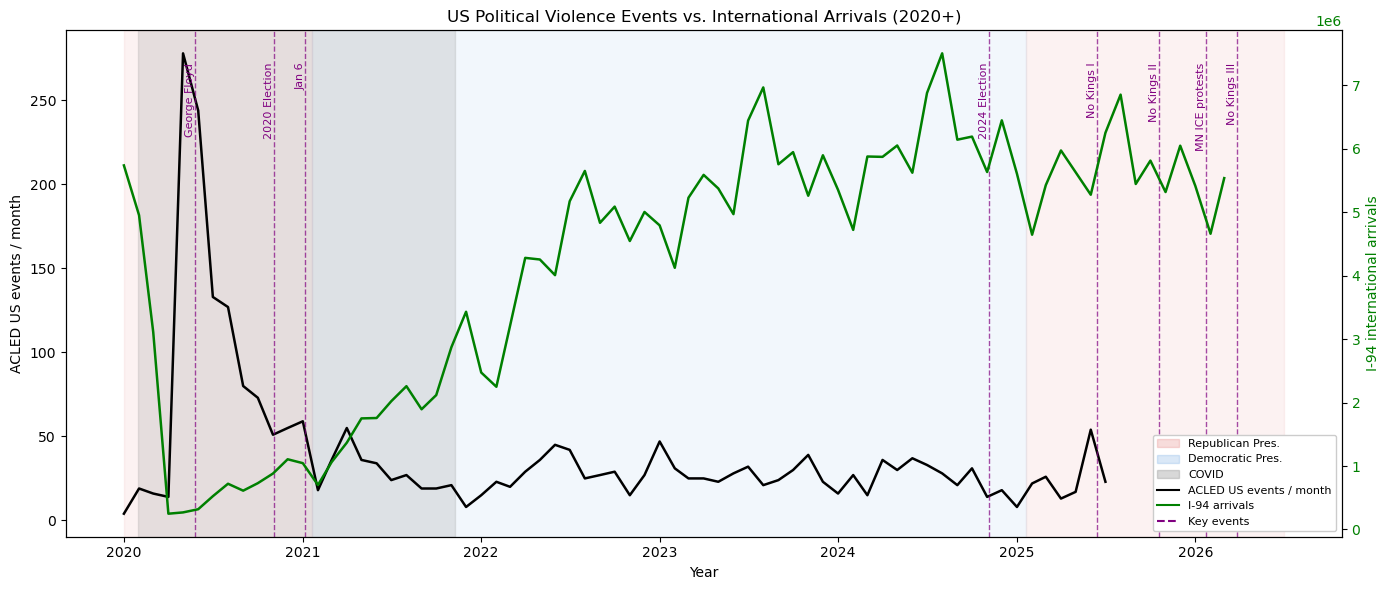

In [13]:
# US political violence events vs. international arrivals (from 2020 onward)
monthly_us = get_us_monthly_events(acled_pv)

# I-94 tourism series from Peter's cleaned file
i94 = pd.read_excel('../Peter_EDA/I94_monthly_arrivals_cleaned.xlsx')
total = i94[i94['Country'] == 'TOTAL ALL COUNTRIES'].iloc[0]    # total arrivals
month_cols = [c for c in i94.columns if str(c)[:4].isdigit()]   # month columns
# print(month_cols)
tourism = total[month_cols].reset_index()                       # total arrivals per month
tourism.columns = ['month', 'arrivals']                         # rename columns
# print(tourism.dtypes)
tourism['month'] = tourism['month'].astype(str).str.replace('Preliminary', '').str.strip()
tourism['month'] = pd.to_datetime(tourism['month'], format='%Y-%m')
tourism['arrivals'] = pd.to_numeric(tourism['arrivals'])
tourism = tourism[(tourism['month'].dt.year >= 2020) & (tourism['arrivals'] > 0)].dropna()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Presidential-party bands
for start, end, color, _ in PARTY_BANDS:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=0.07)

# COVID
ax1.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), color='gray', alpha=0.18)

# Conflict / protest volume (left axis)
ax1.plot(monthly_us['month'], monthly_us['events'], color='black', lw=1.8)
ax1.set_ylabel('ACLED US events / month')
ax1.set_xlabel('Year')

# Key-event markers
ymax = monthly_us['events'].max() if not monthly_us.empty else 1
for date, label in KEY_EVENTS:
    d = pd.Timestamp(date)
    ax1.axvline(d, color='purple', ls='--', lw=1, alpha=0.7)
    ax1.annotate(label, xy=(d, ymax * 0.98), rotation=90, va='top', ha='right',
                 fontsize=8, color='purple')

# I-94 tourism overlay (right axis)
ax2 = ax1.twinx()
ax2.plot(tourism['month'], tourism['arrivals'], color='green', lw=1.8)
ax2.set_ylabel('I-94 international arrivals', color='green')
ax2.tick_params(axis='y', labelcolor='green')

legend = [
    mpatches.Patch(color='#d9534f', alpha=0.2, label='Republican Pres.'),
    mpatches.Patch(color='#4a90d9', alpha=0.2, label='Democratic Pres.'),
    mpatches.Patch(color='gray',    alpha=0.3, label='COVID'),
    plt.Line2D([], [], color='black',  label='ACLED US events / month'),
    plt.Line2D([], [], color='green',  label='I-94 arrivals'),
    plt.Line2D([], [], color='purple', ls='--', label='Key events'),
]
ax1.legend(handles=legend, loc='lower right', fontsize=8, framealpha=1)
ax1.set_title('US Political Violence Events vs. International Arrivals (2020+)')
plt.tight_layout()
plt.show()

# MORE EDA

For feature engineering

In [14]:
# Is there any relationship between monthly political-violence events and monthly international arrivals?
monthly_events_v_arrivals = monthly_us.merge(tourism, on='month').set_index('month')
monthly_events_v_arrivals.head()

# Compare pre-COVID, COVID, ex-COVID, and post-COVID periods
pre_covid = monthly_events_v_arrivals.index < COVID_START
covid = (monthly_events_v_arrivals.index >= COVID_START) & (monthly_events_v_arrivals.index < COVID_END)
ex_covid = ~covid
post_covid = monthly_events_v_arrivals.index >= COVID_END

# Helper function that returns Pearson correlation and p-values between arrivals and events
# Correlation requires at least two non-missing observations, so we return NaN for pre-COVID
def corr_p(x, mask):
    d = pd.concat([monthly_events_v_arrivals['arrivals'][mask], x[mask]], axis=1).dropna()
    if len(d) < 2:
        return np.nan, np.nan
    r, p = stats.pearsonr(d.iloc[:, 0], d.iloc[:, 1])
    return round(r, 3), round(p, 3)

# Is there a lagged relationship between political violence and international arrivals?
# International trips are often booked ~1–6 months in advance, so we want to test
# whether political violence may affect tourism with a delayed effect / lagged reaction

rows = []
for lag in range(7):    # Checking same month vs. one to six months prior
    x = monthly_events_v_arrivals['events'].shift(lag)
    rows.append([
        lag,
        *corr_p(x, np.ones(len(monthly_events_v_arrivals), bool)),
        *corr_p(x, pre_covid),
        *corr_p(x, covid),
        *corr_p(x, ex_covid),
        *corr_p(x, post_covid),
    ])

lag_table = pd.DataFrame(
    rows,
    columns=[
        'months_prior',
        'r_2020+', 'p_2020+',
        'r_preCOVID', 'p_preCOVID',
        'r_COVID', 'p_COVID',
        'r_exCOVID', 'p_exCOVID',
        'r_postCOVID', 'p_postCOVID',
    ],
)
print(
    f"Number of months: total={len(monthly_events_v_arrivals)} "
    f"pre-COVID={pre_covid.sum()} "
    f"COVID={covid.sum()} "
    f"ex-COVID={ex_covid.sum()} "
    f"post-COVID={post_covid.sum()}\n"
)
display(lag_table)

# Year-over-year differencing to compare each month to the same month in the previous year
# to reduce the effect of seasonal travel patterns
yoy = pd.concat([
    monthly_events_v_arrivals['events'].diff(12).rename('d_events'),
    monthly_events_v_arrivals['arrivals'].diff(12).rename('d_arrivals'),
], axis=1).dropna()
yoy = yoy[yoy.index >= COVID_END]
r, p = stats.pearsonr(yoy['d_events'], yoy['d_arrivals'])
print(f"\nYoY-differenced, post-COVID: r={r:.3f}, p={p:.3f}, n={len(yoy)}")

Number of months: total=67 pre-COVID=1 COVID=22 ex-COVID=45 post-COVID=44



,months_prior,r_2020+,p_2020+,r_preCOVID,p_preCOVID,r_COVID,p_COVID,r_exCOVID,p_exCOVID,r_postCOVID,p_postCOVID
0,0,-0.492,0.000,NaN,NaN,-0.521,0.013,0.025,0.868,0.049,0.752
1,1,-0.452,0.000,NaN,NaN,-0.487,0.022,0.310,0.040,0.310,0.040
2,2,-0.432,0.000,NaN,NaN,-0.412,0.063,0.321,0.034,0.321,0.034
3,3,-0.417,0.001,NaN,NaN,-0.264,0.261,0.272,0.075,0.272,0.075
4,4,-0.436,0.000,NaN,NaN,-0.276,0.253,0.137,0.373,0.137,0.373
5,5,-0.445,0.000,NaN,NaN,-0.244,0.330,0.100,0.517,0.100,0.517
6,6,-0.445,0.000,NaN,NaN,-0.219,0.399,0.117,0.449,0.117,0.449



YoY-differenced, post-COVID: r=0.073, p=0.638, n=44


For the full dataset (2020+), the correlations are consistently negative and statistically significant. However, these results are driven heavily by the COVID period, where both arrivals and politically-violent events moved in opposite directions during the pandemic shock. Once you split the sample to exclude COVID and post-COVID, the correlations become weak, small, and mostly not significant. The pre-COVID period is not usable here because there is only 1 month in that slice, so NaN values are expected.

The strong negative correlation in the full sample does not mean political violence and arrivals have a strong real relationship. It mainly reflects that COVID disrupted both series at the same time in opposite ways. After COVID, the relationship looks much weaker and basically disappears. There is also no relationship after adjusting for seasonal tourism trends. There is no strong evidence here that political violence is systematically related to international arrivals after accounting for COVID and seasonality.

In [15]:
# Per year dataframe
annual = monthly_events_v_arrivals.copy()
annual['year'] = annual.index.year
annual = annual.groupby('year').agg(
    pv_events=('events', 'sum'),
    months_observed=('events', 'size'),
    arrivals=('arrivals', 'sum'))
annual['events_per_month'] = (annual['pv_events'] / annual['months_observed']).round(1)
annual['arrivals_in_millions'] = (annual['arrivals'] / 1e6).round(1)
display(annual[['pv_events', 'months_observed', 'events_per_month', 'arrivals_in_millions']])

,pv_events,months_observed,events_per_month,arrivals_in_millions
year,,,,
2020,1094,12,91.2,19.2
2021,356,12,29.7,22.3
2022,333,12,27.8,50.8
2023,348,12,29.0,66.3
2024,306,12,25.5,72.3
2025,163,7,23.3,38.8


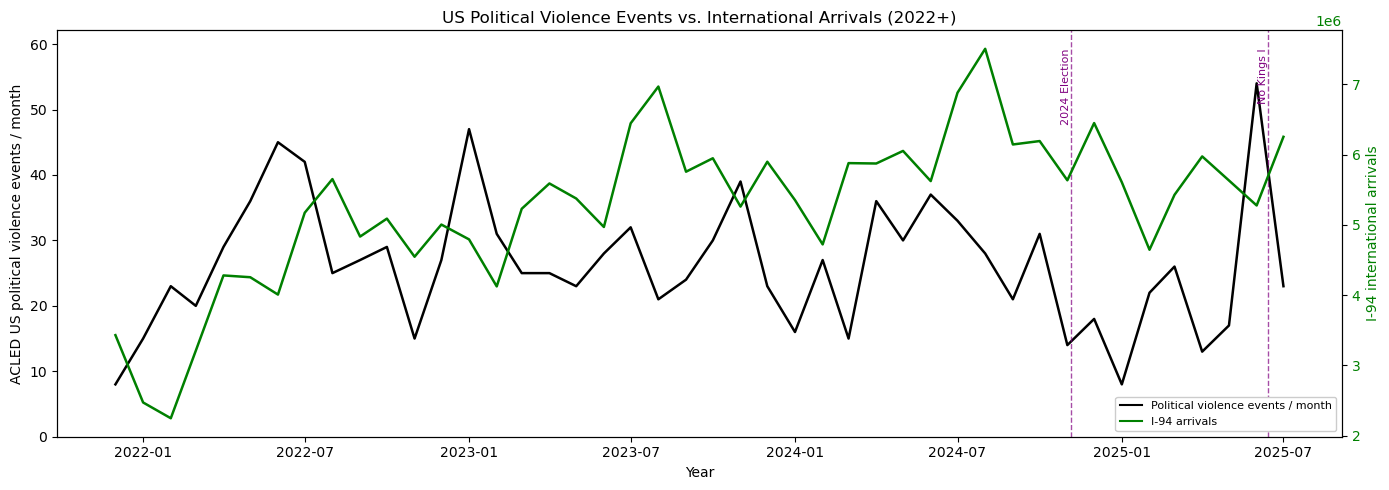

In [16]:
# Plot post-COVID period
sub = monthly_events_v_arrivals[monthly_events_v_arrivals.index >= COVID_END]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(sub.index, sub['events'], color='black', lw=1.8)
ax1.set_ylabel('ACLED US political violence events / month')
ax1.set_ylim(0, sub['events'].max() * 1.15)
ax1.set_xlabel('Year')

ax2 = ax1.twinx()
ax2.plot(sub.index, sub['arrivals'], color='green', lw=1.8)
ax2.set_ylabel('I-94 international arrivals', color='green')
ax2.tick_params(axis='y', labelcolor='green')

for date, label in KEY_EVENTS:
    d = pd.Timestamp(date)
    if sub.index.min() <= d <= sub.index.max():
        ax1.axvline(d, color='purple', ls='--', lw=1, alpha=0.7)
        ax1.annotate(label, xy=(d, sub['events'].max() * 1.1), rotation=90,
                     va='top', ha='right', fontsize=8, color='purple')

ax1.legend(handles=[plt.Line2D([], [], color='black', label='Political violence events / month'),
                    plt.Line2D([], [], color='green', label='I-94 arrivals')],
           loc='lower right', fontsize=8, framealpha=1)
ax1.set_title('US Political Violence Events vs. International Arrivals (2022+)')
plt.tight_layout()
plt.show()

In [17]:
# Does severity of the politicaslly-violent event have any effect?
pv = acled_pv.copy()
pv['fatalities'] = pd.to_numeric(pv['fatalities'], errors='coerce').fillna(0)

g = pv.groupby('month')
sev = pd.DataFrame({
    'events':       g.size(),
    'fatalities':   g['fatalities'].sum(),                                      # total fatalities each month
    'fatal_events': g['fatalities'].apply(lambda x: (x > 0).sum()),             # number of months with >= 1 fatality
    'civ_targeted': g['civilian_targeting'].apply(lambda s: s.notna().sum()),   # number of months where civilians were targeted
})
sev.index = sev.index.to_timestamp()
sev = sev.reindex(pd.date_range(sev.index.min(), sev.index.max(), freq='MS'), fill_value=0)
sev['fatality_rate'] = np.where(sev['events'] > 0, sev['fatalities'] / sev['events'], 0)    # how deadly was each event, on average?

sev_ = sev.join(tourism.set_index('month')['arrivals'], how='inner')
sev_covid  = (sev_.index >= COVID_START) & (sev_.index < COVID_END)
sev_postcovid = sev_.index >= COVID_END

rows = []
for col in ['events', 'fatalities', 'fatal_events', 'civ_targeted', 'fatality_rate']:
    for lag in [0, 3, 6]:
        x = sev_[col].shift(lag)
        def rp(mask):
            d = pd.concat([sev_['arrivals'][mask], x[mask]], axis=1).dropna()
            return stats.pearsonr(d.iloc[:, 0], d.iloc[:, 1])
        rows.append([col, lag, round(rp(np.ones(len(sev_), bool))[0], 3),
                     round(rp(~sev_covid)[0], 3), *[round(v, 3) for v in rp(sev_postcovid)]])

sev_table = pd.DataFrame(rows, columns=['feature', 'months_prior', 'r_2020+', 'r_exCOVID', 'r_postCOVID', 'p_postCOVID'])
n_tests = len(sev_table)
print(f"{n_tests} correlations tested. Using a Bonferroni threshold (p divided by # of tests), p < {0.05/n_tests:.4f}\n")
display(sev_table)

15 correlations tested. Using a Bonferroni threshold (p divided by # of tests), p < 0.0033



,feature,months_prior,r_2020+,r_exCOVID,r_postCOVID,p_postCOVID
0,events,0,-0.492,0.025,0.049,0.752
1,events,3,-0.417,0.272,0.272,0.075
2,events,6,-0.445,0.117,0.117,0.449
3,fatalities,0,-0.200,-0.107,-0.102,0.511
4,fatalities,3,-0.121,-0.071,-0.071,0.646
5,fatalities,6,-0.144,-0.195,-0.195,0.204
6,fatal_events,0,-0.504,-0.263,-0.260,0.088
7,fatal_events,3,-0.493,-0.251,-0.251,0.100
8,fatal_events,6,-0.464,-0.234,-0.234,0.127
9,civ_targeted,0,-0.432,-0.128,-0.115,0.458


The relationship between violence severity and tourism arrivals does not hold once COVID is separated out. In the full 2020+ sample, several measures look negatively correlated with arrivals, but those patterns are likely driven by the pandemic shock rather than an underlying relationship. After COVID, the correlations are small, near zero, and not statistically significant, so there is little evidence that higher violence severity is associated with lower arrivals in the post-COVID period.